<a href="https://colab.research.google.com/github/thrower19/RN_segmentation_model_data/blob/main/RN_model_validation_for_nnlm_and_GT_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
### IMPORTS ###
import pickle
from glob import glob
import pandas as pd
import numpy as np
from google.colab import drive
import os
import seaborn as sns
import re
from itertools import cycle
from plotly.offline import plot
import plotly.graph_objs as go
import matplotlib.cm as cm
import random as rand
import nibabel as nib
import base64
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from io import BytesIO
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV,Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import MultiTaskElasticNetCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from itertools import cycle

In [2]:
### HELPER FUNCTIONS ###
afids_labels = {
    1: 'AC', 2: 'PC', 3: 'ICS', 4: 'PMJ', 5: 'SIPF', 6: 'RSLMS',
    7: 'LSLMS', 8: 'RILMS', 9: 'LILMS', 10: 'CUL', 11: 'IMS', 12: 'RMB',
    13: 'LMB', 14: 'PG', 15: 'RLVAC', 16: 'LLVAC', 17: 'RLVPC', 18: 'LLVPC',
    19: 'GENU', 20: 'SPLE', 21: 'RALTH', 22: 'LALTH', 23: 'RSAMTH',
    24: 'LSAMTH', 25: 'RIAMTH', 26: 'LIAMTH', 27: 'RIGO', 28: 'LIGO',
    29: 'RVOH', 30: 'LVOH', 31: 'ROSF', 32: 'LOSF'
}

#hardcoding right and left hemisphere afids
right_afids = ['x_6','x_8','x_12','x_15','x_17','x_21','x_23','x_25','x_27','x_29','x_31','y_6','y_8','y_12','y_15','y_17','y_21','y_23','y_25','y_27','y_29','y_31', 'z_6','z_8','z_12','z_15','z_17','z_21','z_23','z_25','z_27','z_29','z_31']
left_afids = ['x_7','x_9','x_13','x_16','x_18','x_22','x_24','x_26','x_28','x_30','x_32','y_7','y_9','y_13','y_16','y_18','y_22','y_24','y_26','y_28','y_30','y_32', 'z_7','z_9','z_13','z_16','z_18','z_22','z_24','z_26','z_28','z_30','z_32']
combined_lables = ['AC','PC', 'ICS', 'PMJ','SIPF','SLMS','ILMS','CUL','IMS','MB','PG','LVAC','LVPC','GENU','SPLE','ALTH','SAMTH','IAMTH','IGO','VOH','OSF']
combined_lables = [element + axis for axis in ['x', 'y', 'z'] for element in combined_lables]
r = [6,8,12,15,17,21,23,25,27,29,31]
l = [7,9,13,16,18,22,24,26,28,30,32]

# exclude_afids_labels = [10,14,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
exclude_afids_labels = []
# exclude_afids = ['CULx','PGx','GENUx', 'SPLEx', 'ALTHx', 'SAMTHx', 'IAMTHx', 'IGOx','VOHx','OSFx',
#                  'CULy','PGy','GENUy', 'SPLEy', 'ALTHy', 'SAMTHy', 'IAMTHy', 'IGOy','VOHy','OSFy',
#                  'CULz','PGz','GENUz', 'SPLEz', 'ALTHz', 'SAMTHz', 'IAMTHz', 'IGOz','VOHz','OSFz'
#                  ]
# exclude_afids = ['CULx','PGx','LVACx','LVPCx','GENUx', 'SPLEx', 'ALTHx', 'SAMTHx', 'IAMTHx', 'IGOx','VOHx','OSFx',
#                  'CULy','PGy','LVACy','LVPCy','GENUy', 'SPLEy', 'ALTHy', 'SAMTHy', 'IAMTHy', 'IGOy','VOHy','OSFy',
#                  'CULz','PGz','LVACz','LVPCz','GENUz', 'SPLEz', 'ALTHz', 'SAMTHz', 'IAMTHz', 'IGOz','VOHz','OSFz'
#                  ]
exclude_afids = []

def fcsvtodf(fcsv_path):
    """
    Convert a .fcsv file (assumes RAS coordinate system) to a ML-friendly dataframe and return the cleaned xyz coordinates.

    Parameters:
    - fcsv_path: str, path to the .fcsv file

    Returns:
    - df_xyz_clean: pandas.DataFrame with cleaned x, y, z coordinates
    - num_points: int, number of fiducial points
    """

    # Extract the subject ID from the file path (naming is in bids-like)
    subject_id = re.search(r'(sub-\w+)', fcsv_path).group(1)

    # Read in .fcsv file, skip header
    df_raw = pd.read_table(fcsv_path,sep=',',header=2)

    #Extract the x, y, z coordiantes and store them in data science friendly format (i.e., features in cols and subject in rows)
    df_xyz = df_raw[['x','y','z']].melt().transpose()

    #Use number of row in fcsv to make number points
    colnames = [f'{axis}_{i % int(df_raw.shape[0]) + 1}' for axis in ['x', 'y', 'z'] for i in range(int(df_raw.shape[0]))]

    #Reassign features to be descriptive of coordinate
    df_xyz.columns = colnames

    #clean dataframe and pin correct subject name
    df_xyz_clean = df_xyz.drop('variable', axis= 0)
    df_xyz_clean = df_xyz_clean.rename(index={'value': subject_id})
    df_xyz_clean = df_xyz_clean.astype(float)

    return df_xyz_clean, df_raw.shape[0]


def get_fiducial_index(fid):
    """
    Retrieve the index corresponding to the fiducial name or integer.

    Parameters:
    - fid: str or int, fiducial identifier (name or index)

    Returns:
    - int, corresponding fiducial index
    """

    if isinstance(fid, str):
        for idx, name in afids_labels.items():
            if name == fid:
                return idx
    elif isinstance(fid, int):
        return fid
    raise ValueError("Invalid fiducial identifier.")


def compute_distance(fcsv_path, fid1, fid2):
    """
    Compute the Euclidean distance between two fiducials.

    Parameters:
    - fcsv_path: str, path to the .fcsv file
    - fid1, fid2: str or int, fiducial identifiers

    Returns:
    - xyz_diff: numpy.array, difference in x, y, z coordinates
    - distance: float, Euclidean distance between fiducials
    """

    # Retrieve indices of the fiducials
    index1, index2 = get_fiducial_index(fid1), get_fiducial_index(fid2)

    # Load dataframe from the fcsv file
    df = fcsvtodf(fcsv_path)[0]

    # Extract x, y, z coordinates into numpy arrays
    coords1 = df[[f'x_{index1}', f'y_{index1}', f'z_{index1}']].to_numpy()
    coords2 = df[[f'x_{index2}', f'y_{index2}', f'z_{index2}']].to_numpy()

    # Compute the difference as a numpy array
    xyz_diff = coords1 - coords2

    # Compute the Euclidean distance
    distance = np.linalg.norm(xyz_diff)

    return xyz_diff.flatten(), distance


def compute_average(fcsv_path, fid1, fid2):
    """
    Compute the average position between two fiducials.

    Parameters:
    - fcsv_path: str, path to the .fcsv file
    - fid1, fid2: str or int, fiducial identifiers

    Returns:
    - xyz_average: numpy.array, average coordinates (x, y, z) between fiducials
    """

    # Retrieve indices of the fiducials
    index1, index2 = get_fiducial_index(fid1), get_fiducial_index(fid2)

    # Load dataframe from the fcsv file
    df = fcsvtodf(fcsv_path)[0]

    # Extract x, y, z coordinates into numpy arrays
    coords1 = df[[f'x_{index1}', f'y_{index1}', f'z_{index1}']].to_numpy()
    coords2 = df[[f'x_{index2}', f'y_{index2}', f'z_{index2}']].to_numpy()

    # Compute the average as a numpy array
    xyz_average = (coords1 + coords2)/2

    return xyz_average.flatten()


def acpcmatrix(fcsv_path, midline, center_on_mcp = True, write_matrix = False, transform_file_name = None):
    """
    Computes a 4x4 transformation matrix aligning with the AC-PC axis.

    Parameters:
    - fcsv_path: str, path to the .fcsv file
    - midline: str or int, one of the 10 midline AFID points.
    - center_on_mcp: bool, If True, adds translation element to the ACPC matrix (centering on MCP).

    Returns:
    - matrix: np.ndarray, A 4x4 affine transformation matrix.
    """

    # A-P axis
    acpc = compute_distance(fcsv_path, 'AC', 'PC')  # vector from PC to AC
    yAxis = acpc[0] / acpc[1]  # unit vector defining anterior and posterior axis

    # R-L axis
    lataxis = compute_distance(fcsv_path, midline, 'AC')[0] # vector from AC to midline point
    xAxis = np.cross(yAxis, lataxis) # vector defining left and right axis
    xAxis /= np.linalg.norm(xAxis) # unit vector defining left and right axis

    # S-I axis
    zAxis = np.cross(xAxis, yAxis)
    zAxis /= np.linalg.norm(zAxis)

    # Rotation matrix
    rotation = np.vstack([xAxis, yAxis, zAxis])
    translation = np.array([0, 0, 0])

    # Build 4x4 matrix
    matrix = np.eye(4)
    matrix[:3, :3] = rotation
    matrix[:3, 3] = translation

    # Orientation correction for matrix is midpoint placed below ACPC (i.e., at PMJ)
    if matrix[0][0] < 0:
        matrix = matrix * np.array([[-1,-1,-1,0],
                                    [1,1,1,0],
                                    [-1,-1,-1,0],
                                    [0,0,0,1]])

    if center_on_mcp: #need to compute MCP AFTER rotation is applied
        mcp = compute_average(fcsv_path,'AC','PC') #MCP in native
        matrix[:3, 3] = -np.dot(matrix[:3, :3], mcp) # MCP after rotation; negative because we set MCP to (0,0,0)

    if write_matrix:
        generate_slicer_file(matrix, transform_file_name)

    return matrix

def extract_sub_metadata(fcsv_path):
    """
    Extracts subject id, description, and dataset following bids-like structure.

    Parameters:
    - fcsv_path: str, path to the .fcsv file

    Returns:
    - sub_id: str, subject ID
    - description: str, description label
    - dataset: str, dataset
    """

    filename = os.path.basename(fcsv_path)

    sub_id_match = re.search(r'^sub-[A-Za-z0-9]+', filename)
    sub_id = sub_id_match.group() if sub_id_match else 'unknown'

    description_match = re.search(r'desc-([A-Za-z0-9\-]+)', filename)
    description = description_match.group(1) if description_match else 'unknown'

    parts = fcsv_path.split(os.sep)

    dataset = "unknown_dataset"

    for i, part in enumerate(parts):
        if part == 'anat':
            if i >= 3:
                dataset = parts[i - 3]
            break  # exit after finding the first match


    match = re.search(r'_([a-zA-Z0-9]+)\.fcsv', parts[-1])
    if match:
        coord_type = match.group(1)
    else:
        coord_type = "unknown_coordinatetype"

    return sub_id, description, dataset, coord_type



def transform_afids(fcsv_path, midline_fcsv=None, output_dir=None, midpoint='PMJ', save_matrix = False):
    """
    Computes and applies an AC-PC transformation to AFID files and saves an fcsv with transfromed coordinates.

    Parameters:
    - fcsv_path: str, path to the .fcsv file for coordinates to be transformed
    - midline_fcsv: str, path to the .fcsv file which has the midline coordinates
    - output_dir: str, path of the directory to store transformed .fcsv file (if not specified, no output fcsv will be written)
    - midpoint: str or int, any midline AFID point

    Returns:
    - tcoords: np.ndarray, transformed coordinates
    """
    if midline_fcsv:
        # Compute the 4x4 AC-PC transformation matrix
        xfm_txt = acpcmatrix(midline_fcsv, midpoint)
    else:
        xfm_txt = acpcmatrix(fcsv_path, midpoint)

    # Read header lines separately
    with open(fcsv_path, 'r') as file:
        header_lines = [next(file) for _ in range(3)]

    # Read coordinates from the file
    fcsv_df = pd.read_table(fcsv_path, sep=",", header=2)

    # Copy coordinates and apply transformation
    pretfm = fcsv_df.loc[:, ["x", "y", "z"]].copy()
    pretfm["coord"] = 1  # Add a fourth column for homogeneous coordinates
    coords = pretfm.to_numpy()
    thcoords = xfm_txt @ coords.T
    tcoords = thcoords.T[:, :3]  # Remove homogeneous coordinates

    # Substitute new coordinates
    if tcoords.shape == (len(fcsv_df), 3):
        fcsv_df.loc[:, "x"] = tcoords[:, 0]
        fcsv_df.loc[:, "y"] = tcoords[:, 1]
        fcsv_df.loc[:, "z"] = tcoords[:, 2]
    else:
        raise ValueError("New coordinates do not match the number of rows in the original fcsv.")

    if output_dir is not None:
        # Save the transformed coordinates to a new fcsv file
        sub_desc_dataset = extract_sub_metadata(fcsv_path)
        output_filename = f'{sub_desc_dataset[0]}_space-MCP{midpoint}_desc-{sub_desc_dataset[1]}_{sub_desc_dataset[3]}.fcsv'
        output_bids = f"{sub_desc_dataset[2]}/{sub_desc_dataset[3]}_mcp/{sub_desc_dataset[0]}/anat"
        full_out_dir = os.path.join(output_dir, output_bids)
        if not os.path.exists(full_out_dir):
            os.makedirs(full_out_dir)

        output_path = os.path.join(full_out_dir, output_filename)

        # Write the header and updated DataFrame to the new fcsv file with specific formatting
        with open(output_path, 'w') as file:
            file.writelines(header_lines)
            fcsv_df.to_csv(file, sep=",", index=False, header=False, float_format="%.5f")
        if save_matrix:
            # Reconstruct path with approriate extension
            tfm_path = os.path.splitext(output_path)[0] + '.txt'
            generate_slicer_file(xfm_txt,tfm_path)

        print(f"Saved transformed file: {output_filename}")

    return tcoords


def coords_to_fcsv(coords, fcsv_template, fcsv_output):
    """
    Updates an fcsv template file with new coordinates and writes the updated version to a new file.
    Ensures the directory for the output file exists before writing.

    Parameters:
    - coords: ndarray, array of shape (n, 3) containing the coordinates for each fiducial.
    - fcsv_template: str, path to a template fcsv file that can be used as a reference.
    - fcsv_output: str, path where the output fcsv file with updated coordinates will be written.
    """

    # Ensure output directory exists
    output_dir = os.path.dirname(fcsv_output)
    os.makedirs(output_dir, exist_ok=True)

    # Read in the fcsv template
    with open(fcsv_template, "r") as f:
        fcsv = [line.strip() for line in f]

    # Loop over each fiducial in the coordinates
    for fid in range(1, coords.shape[0] + 1):
        # Update fcsv, skipping header lines (first 3 lines assumed to be header)
        line_idx = fid + 2  # Line to update with new coordinates
        centroid_idx = fid - 1  # Index of the current point in coords

        # Replace the placeholders for x, y, and z coordinates
        fcsv[line_idx] = fcsv[line_idx].replace(
            f"afid{fid}_x", str(coords[centroid_idx][0])
        ).replace(
            f"afid{fid}_y", str(coords[centroid_idx][1])
        ).replace(
            f"afid{fid}_z", str(coords[centroid_idx][2])
        )

    # Write the updated fcsv to the output file
    with open(fcsv_output, "w") as f:
        f.write("\n".join(fcsv))



def generate_slicer_file(matrix, filename):
    """
    Generate a .txt transformation file for 3D Slicer from a 4x4 matrix.

    Parameters:
    - matrix: np.ndarray, 4x4 transformation matrix
    - output_path: str, path to store .txt file
    """
    D = np.array([
    [-1,  0,  0, 0],
    [ 0, -1,  0, 0],
    [ 0,  0,  1, 0],
    [ 0,  0,  0, 1]
    ])

    ras_inmatrix = np.linalg.inv(matrix)

    lps_inmatrix = D @ ras_inmatrix @ D

    # Extract rotation/scale and translation components
    rotation_scale = lps_inmatrix[0:3, 0:3].flatten()
    translation = lps_inmatrix[0:3, 3]

    # Format the content of the .tfm file
    tfm_content = "#Insight Transform File V1.0\n"
    tfm_content += "#Transform 0\n"
    tfm_content += "Transform: AffineTransform_double_3_3\n"
    tfm_content += "Parameters: " + " ".join(map(str, rotation_scale)) + " " + " ".join(map(str, translation)) + "\n"
    tfm_content += "FixedParameters: 0 0 0\n"

    # Write the content to the specified file
    with open(filename, 'w') as file:
        file.write(tfm_content)

    print(f"{filename} has been generated.")

def save_single_slice_in_memory(data, x, y, z, offset, zoom_radius, show_crosshairs):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, (slice_data, coord, title) in enumerate(
        zip(
            [data[x + offset, :, :], data[:, y + offset, :], data[:, :, z + offset]],
            [(y, z), (x, z), (x, y)],
            ["Sagittal", "Coronal", "Axial"],
        )
    ):
        axes[i].imshow(slice_data.T, origin='lower', cmap='gray')
        if offset == 0 and show_crosshairs:
            axes[i].axhline(y=coord[1], color='r', lw=1)
            axes[i].axvline(x=coord[0], color='r', lw=1)
        axes[i].set_xlim(coord[0] - zoom_radius, coord[0] + zoom_radius)
        axes[i].set_ylim(coord[1] - zoom_radius, coord[1] + zoom_radius)
        axes[i].set_title(title)
        axes[i].axis('off')

    buffer = BytesIO()
    plt.savefig(buffer, format='png', bbox_inches='tight')
    plt.close(fig)
    buffer.seek(0)

    return base64.b64encode(buffer.read()).decode()

def save_mri_slices_as_images(data, x, y, z, jitter, zoom_radius, show_crosshairs=True):
    return Parallel(n_jobs=-1)(
        delayed(save_single_slice_in_memory)(data, x, y, z, offset, zoom_radius, show_crosshairs)
        for offset in range(-jitter, jitter + 1)
    )

def extract_coordinates_from_fcsv(file_path, label_description):
    df = pd.read_csv(file_path, comment='#', header=None)
    row = df[df[11] == label_description]
    return tuple(row.iloc[0, 1:4]) if not row.empty else None

def generate_html_with_keypress(subject_images, reference_images, output_html="mri_viewer.html"):
    """Generate an interactive HTML viewer with sticky instructions."""
    html_content = """
    <!DOCTYPE html>
    <html lang="en">
    <head>
        <meta charset="UTF-8">
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <title>MRI Viewer</title>
        <style>
            body { display: flex; font-family: Arial, sans-serif; margin: 0; padding: 0; }
            .instructions {
                width: 20%; padding: 20px; background-color: #f4f4f4;
                border-right: 2px solid #ddd;
                position: sticky; top: 0; height: 100vh; overflow-y: auto;
                box-sizing: border-box;
            }
            .instructions h2 { margin-top: 0; }
            .viewer { flex: 1; padding: 20px; text-align: center; }
            .slider { width: 80%; margin: 20px auto; }
            .image { display: block; margin: 0 auto; max-width: 80%; transition: opacity 0.2s ease-in-out; }
        </style>
    </head>
    <body>
        <div class="instructions">
            <h2>Tips & Tricks</h2>
            <ul>
                <li>Use the <strong>slider</strong> to navigate through MRI. Keyboard can also be used after clicking on slider.</li>
                <li>Check the <strong>Red</strong> crosshair which represents the placement of a given landmark.</li>
                <li>Press <strong>R</strong> to toggle between the subject scan and the protocol-defined placement (if one exists).</li>
                <li>Use the <strong>TAB</strong> key to navigate to next slider & MRI.</li>
            </ul>
        </div>
        <div class="viewer">
    """

    for label, images in subject_images.items():
        num_slices = len(images)
        has_reference = reference_images is not None and label in reference_images

        html_content += f"""
        <div class="container">
            <h2>Landmark: {label}</h2>
            <img id="{label}_image" class="image" src="data:image/png;base64,{images[0]}" alt="MRI Slice">
            <input type="range" min="0" max="{num_slices - 1}" value="0" class="slider" id="{label}_slider">
        </div>
        """

    html_content += """
        </div>
        <script>
            const subjects = {};
    """

    for label, images in subject_images.items():
        has_reference = reference_images is not None and label in reference_images
        html_content += f"""
            subjects["{label}"] = {{
                targetImages: {images},
                referenceImages: {reference_images[label] if has_reference else "null"},
                showingReference: false
            }};
        """

    html_content += """
            document.addEventListener('DOMContentLoaded', () => {
                for (const [label, data] of Object.entries(subjects)) {
                    const slider = document.getElementById(`${label}_slider`);
                    const image = document.getElementById(`${label}_image`);

                    slider.addEventListener('input', () => updateImage(label));
                    document.addEventListener('keydown', (event) => {
                        if (event.key.toLowerCase() === 'r' && data.referenceImages) {
                            data.showingReference = !data.showingReference;
                            updateImage(label);
                        }
                    });

                    function updateImage(label) {
                        const sliceIndex = document.getElementById(`${label}_slider`).value;
                        const imageArray = subjects[label].showingReference
                            ? subjects[label].referenceImages
                            : subjects[label].targetImages;
                        document.getElementById(`${label}_image`).src = 'data:image/png;base64,' + imageArray[sliceIndex];
                    }
                }
            });
        </script>
    </body>
    </html>
    """

    with open(output_html, "w") as f:
        f.write(html_content)

def generate_interactive_mri_html(nii_path, fcsv_path, labels, ref_nii_path=None, ref_fcsv_path=None, jitter=2, zoom_radius=20, out_file_prefix="mri_viewer"):
    """
    Generates an interactive HTML viewer for MRI slices based on fiducial coordinates for a single subject.

    Parameters:
    - nii_path: str
        Full path to the subject's NIfTI (.nii.gz) file.
    - fcsv_path: str
        Full path to the subject's FCSV (.fcsv) file.
    - labels: list of int
        Landmark indices to extract for the subject.
    - ref_nii_path: str or None
        Full path to reference NIfTI file (optional).
    - ref_fcsv_path: str or None
        Full path to reference FCSV file (optional).
    - jitter: int, optional (default=2)
        The number of pixels to expand around the coordinate in each slice for visualization.
    - zoom_radius: int, optional (default=20)
        The radius (in pixels) around the coordinate to extract for display.
    - out_file_prefix: str, optional (default="mri_viewer")
        The prefix for the output HTML file name.

    Notes:
    - Extracts specified fiducial coordinates from the subject's .fcsv file.
    - Maps the coordinates from world space to voxel space using the NIfTI affine transformation.
    - MRI slices centered around these coordinates are saved as images.
    - If a reference MRI and coordinate file are provided, the same process is applied.
    - Generates an interactive HTML viewer allowing keypress navigation.

    Returns:
    - None (outputs an HTML file with the interactive MRI viewer for the subject).
    """
    subject_key = os.path.basename(nii_path).replace(".nii.gz", "")
    target_img = nib.load(nii_path, mmap=True)
    affine_inv = np.linalg.inv(target_img.affine)
    target_data = target_img.get_fdata(dtype=np.float32)

    target_images = {}  # Dictionary to store images per landmark

    for label in labels:
        target_coord = extract_coordinates_from_fcsv(fcsv_path, label)
        if not target_coord:
            print(f"Coordinates for label '{label}' not found in subject '{subject_key}'.")
            continue

        target_voxel = np.round(affine_inv.dot(target_coord + (1,))).astype(int)
        target_images[label] = save_mri_slices_as_images(target_data, *target_voxel[:3], jitter, zoom_radius)

    reference_images = None
    if ref_nii_path and ref_fcsv_path:
        ref_img = nib.load(ref_nii_path, mmap=True)
        ref_data = ref_img.get_fdata(dtype=np.float32)
        reference_images = {}

        for label in labels:
            ref_coord = extract_coordinates_from_fcsv(ref_fcsv_path, label)
            if ref_coord:
                ref_voxel = np.round(np.linalg.inv(ref_img.affine).dot(ref_coord + (1,))).astype(int)
                reference_images[label] = save_mri_slices_as_images(ref_data, *ref_voxel[:3], jitter, zoom_radius)
    os.makedirs(out_file_prefix, exist_ok=True)

    out_file = f"{out_file_prefix}{subject_key}.html"

    print(f"Generated: {out_file}")

    # Pass the correct image dictionaries
    generate_html_with_keypress(target_images, reference_images, out_file)

def flip_and_concatenate_hemispheres(df_afids):
    """
    Flips hemispheres by removing left/right AFIDs, relabels columns, and concatenates
    mirrored and non-mirrored data.

    Parameters:
        df_afids (pd.DataFrame): Original DataFrame of AFID coordinates.
        afidutils (module or object): Utility with attributes:
            - left_afids (list): Column names for left hemisphere AFIDs.
            - right_afids (list): Column names for right hemisphere AFIDs.
            - combined_lables (list): Unified column names after hemisphere flip.
            - exclude_afids (list): Columns to exclude from final DataFrame.

    Returns:
        pd.DataFrame: Combined and cleaned DataFrame with flipped hemispheres.
    """
    df_afids_mcp_l = df_afids.copy()
    df_afids_mcp_l[[col for col in df_afids.columns if 'x' in col]] *= -1

    # Drop left hemisphere from one copy, right from the other
    df_afids_mcp = df_afids.drop(left_afids, axis=1)
    df_afids_mcp_l = df_afids_mcp_l.drop(right_afids, axis=1)

    # Rename columns to have consistent structure
    df_afids_mcp.columns = combined_lables
    df_afids_mcp_l.columns = combined_lables

    # Concatenate mirrored and original data
    concatenated_df = pd.concat([df_afids_mcp, df_afids_mcp_l])

    return concatenated_df


def predict_stn_coordinates(
    subject_afid_path,
    model_path
):
    """
    Runs the trained AFIDs -> STN model on a single subject and returns predicted coordinates.

    Parameters
    ----------
    subject_afid_path : str
        Path to the subject's .fcsv AFID file in ACPC + mcp centered space.
    model_path : str
        Path to the trained model pickle file.
    afidutils : module
        AFID utility module, must include:
        - fcsvtodf()
        - left_afids, right_afids, combined_lables, exclude_afids

    Returns
    -------
    y_pred : np.ndarray
        Predicted STN coordinates, shape (82, 3).
    """

    # Load subject AFIDs
    df = fcsvtodf(subject_afid_path)[0]

    # values between -0.01 and 0.01 are set to zero
    df.map(make_zero)

    df_proc = flip_and_concatenate_hemispheres(df)

    # Load model
    with open(model_path, 'rb') as file:
        model_dict = pickle.load(file)

    scaler = model_dict['standard_scaler']
    pca = model_dict['pca']
    ridge_models = [model_dict['x'], model_dict['y'], model_dict['z']]

    # Transform
    X = scaler.transform(df_proc.values)
    X = pca.transform(X)

    # Predict STN
    y_pred = np.column_stack([ridge.predict(X) for ridge in ridge_models])

    return y_pred

def make_zero(num, threshold=0.01):
    if abs(num) < threshold:
        return 0
    else:
        return num

def remove_outliers(df, cols, threshold=3.5):
    """
    Remove rows from a DataFrame based on a modified Z-score for a given column(s).
    """
    for col in cols:
        median = np.median(df[col])
        mad = np.median(np.abs(df[col] - median))
        if mad == 0:
            mad = 1.0
        z_scores = 0.6745 * (df[col] - median) / mad
        df = df.loc[abs(z_scores) < threshold]
    return df

def create_list(n):
    numbers = list(range(1, n + 1))  # Create a list of numbers from 1 to n
    repeated_numbers = cycle(numbers)  # Create a cycle iterator for the numbers
    result = [next(repeated_numbers) for _ in range(n * 2)]  # Generate n*2 elements by cycling through the numbers
    return result

def determineFCSVCoordSystem(input_fcsv, overwrite_fcsv=False):
    # need to determine if file is in RAS or LPS
    # loop through header to find coordinate system
    coordFlag = re.compile("# CoordinateSystem")
    verFlag = re.compile("# Markups fiducial file version")
    headFlag = re.compile("# columns")
    coord_sys = None
    headFin = None
    ver_fin = None

    with open(input_fcsv, "r") as myfile:
        firstNlines = myfile.readlines()[0:3]

    for row in firstNlines:
        row = re.sub("[\s\,]+[\,]", "", row).replace("\n", "")
        cleaned_dict = {row.split("=")[0].strip(): row.split("=")[1].strip()}
        if None in list(cleaned_dict):
            cleaned_dict["# columns"] = cleaned_dict.pop(None)
        if any(coordFlag.match(x) for x in list(cleaned_dict)):
            coord_sys = list(cleaned_dict.values())[0]
        if any(verFlag.match(x) for x in list(cleaned_dict)):
            verString = list(filter(verFlag.match, list(cleaned_dict)))
            assert len(verString) == 1
            ver_fin = verString[0].split("=")[-1].strip()
        if any(headFlag.match(x) for x in list(cleaned_dict)):
            headFin = list(cleaned_dict.values())[0].split(",")

    if any(x in coord_sys for x in {"LPS", "1"}):
        df = pd.read_csv(input_fcsv, skiprows=3, header=None)

        if df.shape[1] != 13:
            df = df.iloc[:, :14]

        df[1] = -1 * df[1]  # flip orientation in x
        df[2] = -1 * df[2]  # flip orientation in y

        if overwrite_fcsv:
            with open(input_fcsv, "w") as fid:
                fid.write("# Markups fiducial file version = 4.11\n")
                fid.write("# CoordinateSystem = 0\n")
                fid.write(
                    "# columns = id,x,y,z,ow,ox,oy,oz,vis,sel,lock,label,desc,associatedNodeID\n"
                )

            df.rename(
                columns={
                    0: "node_id",
                    1: "x",
                    2: "y",
                    3: "z",
                    4: "ow",
                    5: "ox",
                    6: "oy",
                    7: "oz",
                    8: "vis",
                    9: "sel",
                    10: "lock",
                    11: "label",
                    12: "description",
                    13: "associatedNodeID",
                },
                inplace=True,
            )

            df["associatedNodeID"] = pd.Series(np.repeat("", df.shape[0]))
            df.round(6).to_csv(
                input_fcsv,
                sep=",",
                index=False,
                lineterminator="",
                mode="a",
                header=False,
                float_format="%.6f",
            )

            # print(
            #     f"Converted LPS to RAS: {os.path.dirname(input_fcsv)}/{os.path.basename(input_fcsv)}"
            # )
    return coord_sys, headFin

<>:702: SyntaxWarning:

invalid escape sequence '\s'

<>:702: SyntaxWarning:

invalid escape sequence '\s'

/tmp/ipykernel_1296/1983037724.py:702: SyntaxWarning:

invalid escape sequence '\s'



In [3]:
# Step 1: Remove the existing cloned directory
!rm -rf /content/RN_segmentation_model_data
print("Existing 'zona_project_data' directory removed.")

Existing 'zona_project_data' directory removed.


In [4]:
!git clone https://github.com/thrower19/RN_segmentation_model_data.git #Clone coordinate data

Cloning into 'RN_segmentation_model_data'...
remote: Enumerating objects: 1538, done.
remote: Counting objects: 100% (1538/1538), done.
remote: Compressing objects: 100% (303/303), done.
remote: Total 1538 (delta 1116), reused 1502 (delta 1089), pack-reused 0 (from 0)
Receiving objects: 100% (1538/1538), 2.28 MiB | 9.47 MiB/s, done.
Resolving deltas: 100% (1116/1116), done.


In [5]:
### Variables ###
%config InlineBackend.figure_format = 'retina' #to make plots look sharper
ANALYSIS = 'RN'

In [6]:
# Path to AFIDs ground truth directory for the current dataset
dirafids_GT = f"/content/RN_segmentation_model_data/model_predictions_nnlm_inputs/GT_model_RN_pred"
dirafids_nnlm = f"/content/RN_segmentation_model_data/model_predictions_nnlm_inputs/nnlm_model_RN_pred"


SUBJIDs_DBS = sorted(list(set(
name.split('_')[0]
for name in os.listdir(dirafids_GT)
if name.startswith("sub-")
)))
print(SUBJIDs_DBS)

for subjid_DBS in SUBJIDs_DBS:
    print(subjid_DBS)

    # Path for nnlm autoafids for the current subject
    fid_fcsv_DBS = sorted(glob(f"{dirafids_GT}/{subjid_DBS}/ses-preop/afids-cnn/{subjid_DBS}*_ses-preop_acq-ax_run-01_desc-afidscnn-nnlm_afids.fcsv"))[0]

    determineFCSVCoordSystem(fid_fcsv_DBS, overwrite_fcsv=True)

    transform_afids(
        fid_fcsv_DBS,
        output_dir=f'{dirafids_GT}/ACPC', # bids-like outputs (fcsv file + transformation matrix)
        save_matrix=True #saves transformation matrix
    )

    # Path for Ground Truth DBS for the current subject
    GT_DBS_fcsv = sorted(glob(f"/content/RN_segmentation_model_data/patient_RN_centroids/{subjid_DBS}_RN_contacts.fcsv"))[0]

    determineFCSVCoordSystem(GT_DBS_fcsv, overwrite_fcsv=True)

    transform_afids(
        GT_DBS_fcsv,
        fid_fcsv_DBS, #need the AFID file to compute ACPC matrix
        output_dir=f'{dirafids_GT}/ACPC/GT_DBS', # bids-like outputs (fcsv file + transformation matrix)
        save_matrix=True #saves transformation matrix
    )

    # Path for nnlm trained Model for the current subject
    nnlm_MODEL_fcsv = sorted(glob(f"{dirafids_nnlm}/{subjid_DBS}/ses-preop/stereotaxy/{subjid_DBS}*_ses-preop_acq-ax_run-01_desc-RN_native.fcsv"))[0]

    determineFCSVCoordSystem(nnlm_MODEL_fcsv, overwrite_fcsv=True)

    transform_afids(
        nnlm_MODEL_fcsv,
        fid_fcsv_DBS, #need the AFID file to compute ACPC matrix
        output_dir=f'{dirafids_nnlm}/ACPC/MODEL_nnlm',
        save_matrix=True #saves transformation matrix
    )

 # Path for GT trained Model for the current subject
    GT_MODEL_fcsv = sorted(glob(f"{dirafids_GT}/{subjid_DBS}/ses-preop/stereotaxy/{subjid_DBS}*_ses-preop_acq-ax_run-01_desc-RN_native.fcsv"))[0]

    determineFCSVCoordSystem(GT_MODEL_fcsv, overwrite_fcsv=True)

    transform_afids(
        GT_MODEL_fcsv,
        fid_fcsv_DBS, #need the AFID file to compute ACPC matrix
        output_dir=f'{dirafids_GT}/ACPC/MODEL_GT',
        save_matrix=True #saves transformation matrix
    )

['sub-P165', 'sub-P167', 'sub-P175', 'sub-P182', 'sub-P193', 'sub-P202', 'sub-P205', 'sub-P213', 'sub-P214', 'sub-P221', 'sub-P256', 'sub-P277', 'sub-P281', 'sub-P289', 'sub-P292', 'sub-P293', 'sub-P310', 'sub-P328', 'sub-P350', 'sub-P352', 'sub-P353', 'sub-P355', 'sub-P359', 'sub-P367', 'sub-P369', 'sub-P374']
sub-P165
/content/RN_segmentation_model_data/model_predictions_nnlm_inputs/GT_model_RN_pred/ACPC/unknown_dataset/afids_mcp/sub-P165/anat/sub-P165_space-MCPPMJ_desc-afidscnn-nnlm_afids.txt has been generated.
Saved transformed file: sub-P165_space-MCPPMJ_desc-afidscnn-nnlm_afids.fcsv
/content/RN_segmentation_model_data/model_predictions_nnlm_inputs/GT_model_RN_pred/ACPC/GT_DBS/unknown_dataset/contacts_mcp/sub-P165/anat/sub-P165_space-MCPPMJ_desc-unknown_contacts.txt has been generated.
Saved transformed file: sub-P165_space-MCPPMJ_desc-unknown_contacts.fcsv
/content/RN_segmentation_model_data/model_predictions_nnlm_inputs/nnlm_model_RN_pred/ACPC/MODEL_nnlm/unknown_dataset/native_

### Model Evaluation for DBS Data ###

In [7]:
import glob
from scipy.stats import wilcoxon
from tabulate import tabulate

dirafids_DBS = f"/content/RN_segmentation_model_data/GT_model_RN_preds"

# Assign hemispheres (assuming 2 points per subject, first is R, second is L)
def assign_hemisphere_model(df):
    df = df.copy()
    df['hemisphere'] = df.groupby("subjectid").cumcount().map({0: "R", 1: "L"})
    return df

def get_ordered_coords(df_raw_single_row, num_points):
    """
    Reorders flattened coordinates from fcsvtodf (x_1, x_2..., y_1, y_2..., z_1, z_2...)
    to (x1, y1, z1, x2, y2, z2...) for correct reshaping.
    """
    ordered_vals = []
    for i in range(1, num_points + 1):
        ordered_vals.append(df_raw_single_row[f'x_{i}'].iloc[0])
        ordered_vals.append(df_raw_single_row[f'y_{i}'].iloc[0])
        ordered_vals.append(df_raw_single_row[f'z_{i}'].iloc[0])
    return np.array(ordered_vals).reshape(num_points, 3)

# Initialize containers for subject IDs, predictions, and ground truths
subsindex_dbs = []
all_nnlm_model_dbs = []
all_GT_model_dbs = []
all_gt_dbs = []
dataset_dbs = []

# Iterate over each DBS subject ID (from cell YTUGD3uTRZOS)
for subjectid_dbs in SUBJIDs_DBS:
    print(f"Processing DBS subject: {subjectid_dbs}")

    # Locate fct ground truth file path in ACPC space
    GT_DBS_fct_fcsv_path = sorted(glob.glob(f"{dirafids_GT}/ACPC/GT_DBS/unknown_dataset/contacts_mcp/{subjectid_dbs}/anat/{subjectid_dbs}_space-MCPPMJ_desc-unknown_contacts.fcsv"))
    nnlm_MODEL_fcsv_path = sorted(glob.glob(f"{dirafids_nnlm}/ACPC/MODEL_nnlm/unknown_dataset/native_mcp/{subjectid_dbs}/anat/{subjectid_dbs}_space-MCPPMJ_desc-*_native.fcsv"))
    GT_MODEL_fcsv_path = sorted(glob.glob(f"{dirafids_GT}/ACPC/MODEL_GT/unknown_dataset/native_mcp/{subjectid_dbs}/anat/{subjectid_dbs}_space-MCPPMJ_desc-*_native.fcsv"))

    if not(GT_DBS_fct_fcsv_path and nnlm_MODEL_fcsv_path and GT_MODEL_fcsv_path):
        print(f"  Error: Files not found for {subjectid_dbs}. Skipping.")
        continue

    GT_DBS_fct_fcsv_path = GT_DBS_fct_fcsv_path[0]
    nnlm_MODEL_fcsv_path = nnlm_MODEL_fcsv_path[0]
    GT_MODEL_fcsv_path = GT_MODEL_fcsv_path[0]

    # Load and process ground truth coordinates
    df_gt_dbs_raw, num_gt_points = fcsvtodf(GT_DBS_fct_fcsv_path)
    df_nnlm_model_dbs_raw, num_nnlm_points = fcsvtodf(nnlm_MODEL_fcsv_path)
    df_GT_model_dbs_raw, num_GT_points = fcsvtodf(GT_MODEL_fcsv_path)


    if not (num_gt_points == num_GT_points == num_nnlm_points):
        print(f"  Error: Number of points in {subjectid_dbs} doesn't match. Skipping.")
        continue

    gt_dbs_coords_reshaped = get_ordered_coords(df_gt_dbs_raw, num_gt_points)
    nnlm_model_dbs_coords_reshaped = get_ordered_coords(df_nnlm_model_dbs_raw, num_nnlm_points)
    GT_model_dbs_coords_reshaped = get_ordered_coords(df_GT_model_dbs_raw, num_GT_points)


    all_nnlm_model_dbs.append(nnlm_model_dbs_coords_reshaped)
    all_GT_model_dbs.append(GT_model_dbs_coords_reshaped)
    all_gt_dbs.append(gt_dbs_coords_reshaped)

    subsindex_dbs.extend([subjectid_dbs, subjectid_dbs])



Processing DBS subject: sub-P165
Processing DBS subject: sub-P167
Processing DBS subject: sub-P175
Processing DBS subject: sub-P182
Processing DBS subject: sub-P193
Processing DBS subject: sub-P202
Processing DBS subject: sub-P205
Processing DBS subject: sub-P213
Processing DBS subject: sub-P214
Processing DBS subject: sub-P221
Processing DBS subject: sub-P256
Processing DBS subject: sub-P277
Processing DBS subject: sub-P281
Processing DBS subject: sub-P289
Processing DBS subject: sub-P292
Processing DBS subject: sub-P293
Processing DBS subject: sub-P310
Processing DBS subject: sub-P328
Processing DBS subject: sub-P350
Processing DBS subject: sub-P352
Processing DBS subject: sub-P353
Processing DBS subject: sub-P355
Processing DBS subject: sub-P359
Processing DBS subject: sub-P367
Processing DBS subject: sub-P369
Processing DBS subject: sub-P374


In [8]:
gt_coords_stacked = np.vstack(all_gt_dbs)
nnlm_model_coords_stacked = np.vstack(all_nnlm_model_dbs)
GT_model_coords_stacked = np.vstack(all_GT_model_dbs)

df_gt_dbs = pd.DataFrame(gt_coords_stacked, columns=['FCTx', 'FCTy', 'FCTz'])
df_nnlm_model_dbs = pd.DataFrame(nnlm_model_coords_stacked, columns=['FCTx', 'FCTy', 'FCTz'])
df_GT_model_dbs = pd.DataFrame(GT_model_coords_stacked, columns=['FCTx', 'FCTy', 'FCTz'])

df_gt_dbs['subjectid'] = subsindex_dbs
df_nnlm_model_dbs['subjectid'] = subsindex_dbs
df_GT_model_dbs['subjectid'] = subsindex_dbs

df_gt_dbs = assign_hemisphere_model(df_gt_dbs)
df_nnlm_model_dbs = assign_hemisphere_model(df_nnlm_model_dbs)
df_GT_model_dbs = assign_hemisphere_model(df_GT_model_dbs)

# Perform subtraction only on numeric columns
GT_delta = (df_GT_model_dbs[['FCTx', 'FCTy', 'FCTz']] - df_gt_dbs[['FCTx', 'FCTy', 'FCTz']])**2
GT_delta.columns = ['MSEx', 'MSEy', 'MSEz']

# Compute Euclidean Distance
GT_delta['ED'] = np.sqrt(GT_delta['MSEx'] + GT_delta['MSEy'] + GT_delta['MSEz'])

GT_delta['subjectid'] = subsindex_dbs
GT_delta['hemisphere'] = df_gt_dbs['hemisphere']

nnlm_delta = (df_nnlm_model_dbs[['FCTx', 'FCTy', 'FCTz']] - df_gt_dbs[['FCTx', 'FCTy', 'FCTz']])**2
nnlm_delta.columns = ['MSEx', 'MSEy', 'MSEz']

# Compute Euclidean Distance
nnlm_delta['ED'] = np.sqrt(nnlm_delta['MSEx'] + nnlm_delta['MSEy'] + nnlm_delta['MSEz'])

nnlm_delta['subjectid'] = subsindex_dbs
nnlm_delta['hemisphere'] = df_gt_dbs['hemisphere']



In [9]:
GT_delta.describe()

,MSEx,MSEy,MSEz,ED
count,52.000000,52.000000,52.000000,52.000000
mean,0.284446,0.463346,0.340052,0.961229
std,0.428075,0.628727,0.378466,0.408775
min,0.000373,0.000159,0.000010,0.214462
25%,0.019876,0.026050,0.071718,0.683031
50%,0.100824,0.233552,0.149028,0.872616
75%,0.341439,0.572753,0.549001,1.274504
max,2.071124,2.588688,1.440288,1.880866


In [10]:
nnlm_delta.describe()

,MSEx,MSEy,MSEz,ED
count,52.000000,52.000000,52.000000,52.000000
mean,0.221894,0.279340,0.174634,0.769190
std,0.258071,0.363691,0.215199,0.293028
min,0.002034,0.000071,0.000053,0.243876
25%,0.031115,0.032254,0.021706,0.554313
50%,0.096053,0.160249,0.079181,0.726771
75%,0.397022,0.361562,0.258351,0.953328
max,1.241152,1.855262,0.938283,1.456298


In [11]:
melted_GT_delta_errors = pd.melt(GT_delta, id_vars=['subjectid', 'hemisphere'], value_vars=['MSEx', 'MSEy', 'MSEz', 'ED'], var_name='metric', value_name='error')

In [12]:
print(melted_GT_delta_errors)

    subjectid hemisphere metric     error
0    sub-P165          R   MSEx  1.336359
1    sub-P165          L   MSEx  0.017644
2    sub-P167          R   MSEx  0.045531
3    sub-P167          L   MSEx  1.164716
4    sub-P175          R   MSEx  0.084466
..        ...        ...    ...       ...
203  sub-P367          L     ED  0.562639
204  sub-P369          R     ED  1.880866
205  sub-P369          L     ED  0.908986
206  sub-P374          R     ED  0.877836
207  sub-P374          L     ED  0.667069

[208 rows x 4 columns]


In [13]:
melted_nnlm_delta_errors = pd.melt(nnlm_delta, id_vars=['subjectid', 'hemisphere'], value_vars=['MSEx', 'MSEy', 'MSEz', 'ED'], var_name='metric', value_name='error')

In [14]:
pip install ptitprince

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 45.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptitprince: filename=ptitprince-0.3.1-py3-none-any.whl size=16216 sha256=7972861695e288b83945d3fc31eaf6de068ce6984b80855b0febfcdf3ae74e5f
  Stored in directory: /root/.cache/pip/wheels/5d/79/49/b89a41fd3d8780ce2c21c7f2debe45f3c6b08d8aef400e3df1
Successfully built ptitprince


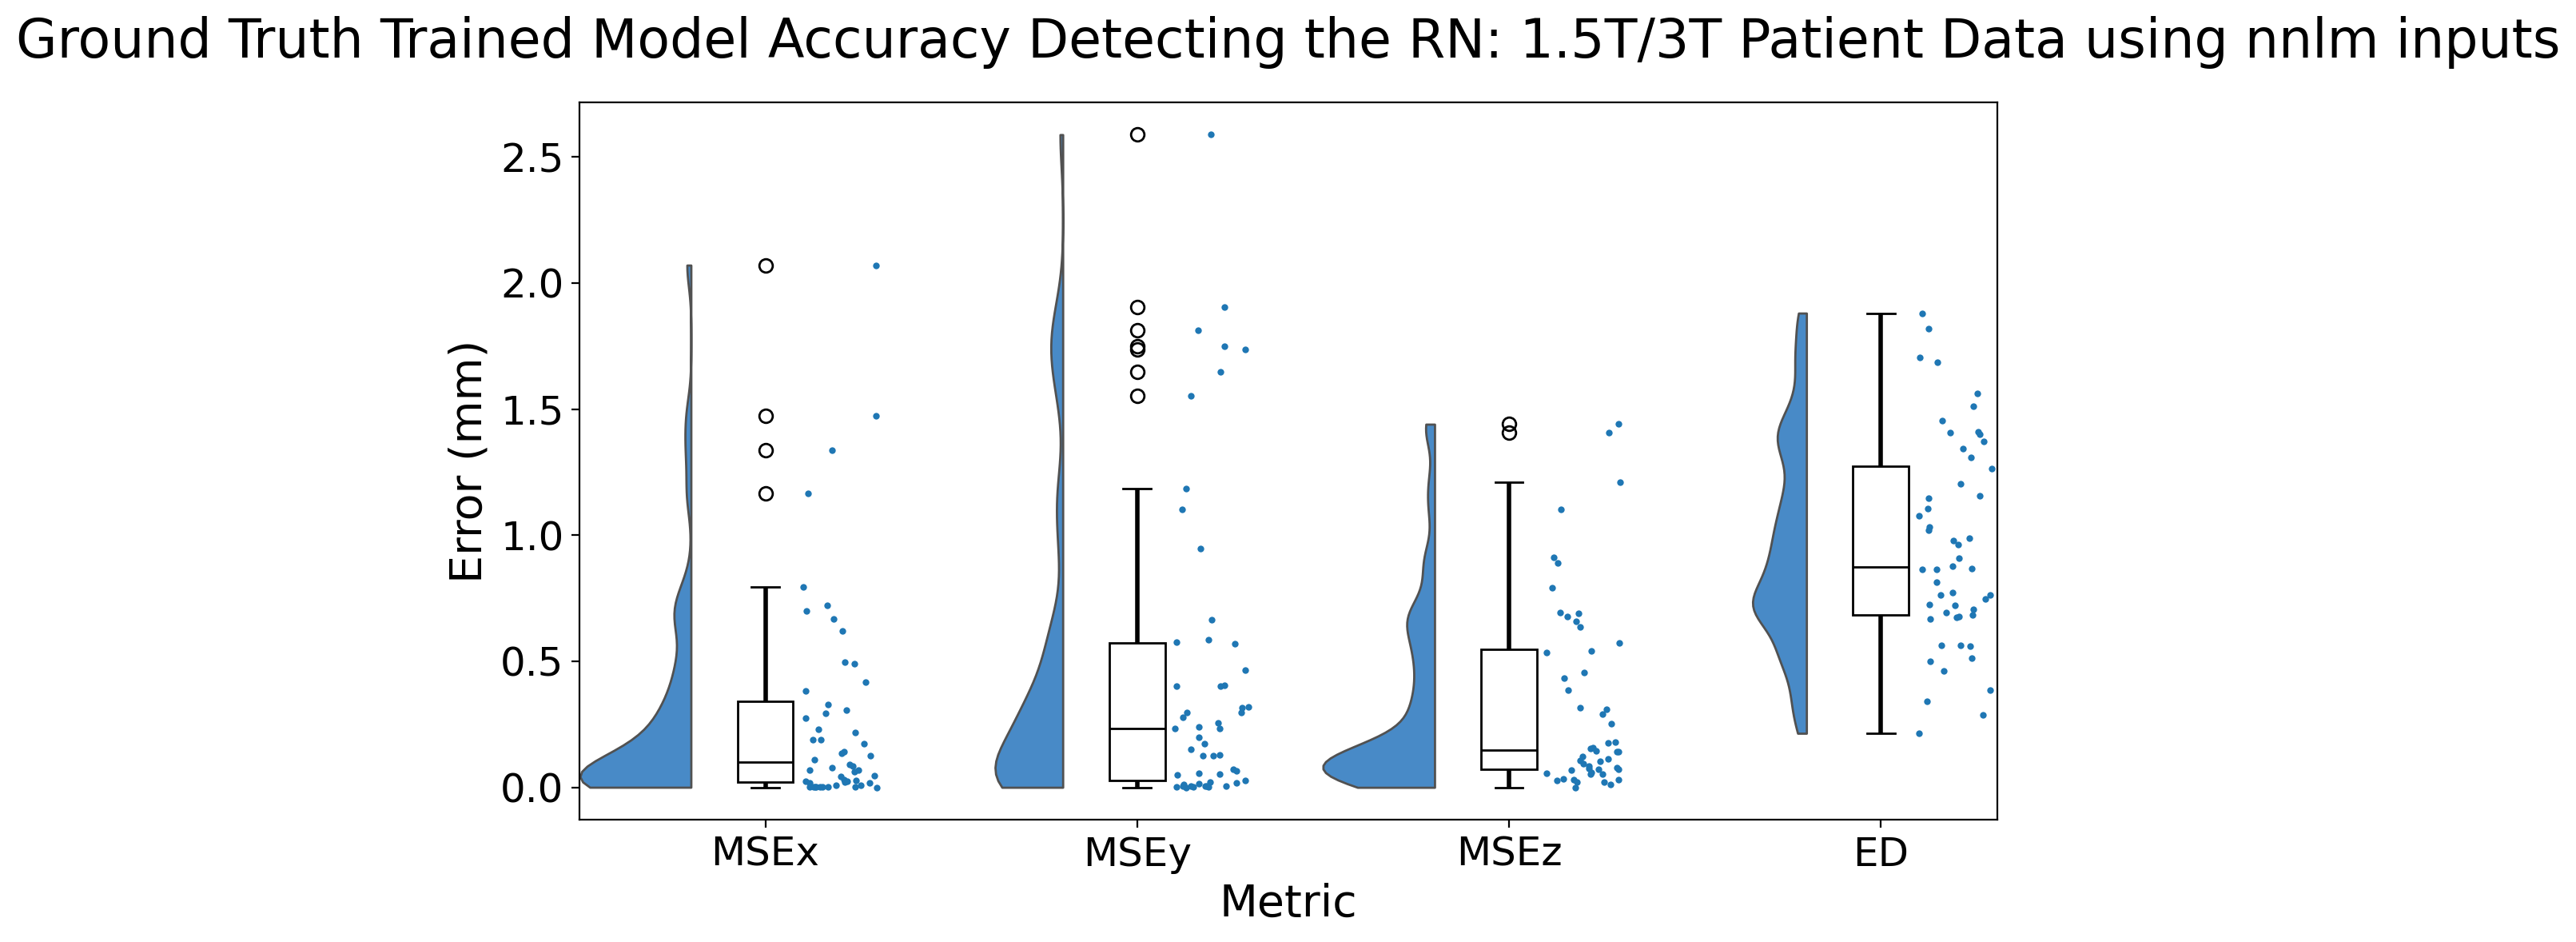

In [15]:
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns

# 1. Load a standard sample dataset from Seaborn
GT_df = melted_GT_delta_errors

# 2. Initialize the matplotlib figure object
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the raincloud plot using ptitprince
# x is the categorical grouping variable, y is the numeric target variable
pt.RainCloud(
    x="metric",
    y="error",
    data=GT_df,
    color="#488AC7",  # Changed to a single color argument to avoid palette warning
    bw=0.2,  # Smoothness of the violin curve (bandwidth)
    width_viol=0.6,  # Width of the half-violin
    orient="v",  # Changed to 'v' for vertical layout
    move=0.2,  # Controls spacing between components
    ax=ax,
)

# 4. Clean up labels and display
ax.set_title("Ground Truth Trained Model Accuracy Detecting the RN: 1.5T/3T Patient Data using nnlm inputs", fontsize=24, pad=20) # Increased pad for better spacing
ax.set_xlabel("Metric", fontsize=20) # Swapped labels for vertical orientation
ax.set_ylabel("Error (mm)", fontsize=20) # Swapped labels for vertical orientation

# Increase tick label font size
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

plt.tight_layout()
plt.show()

### DBS Model Accuracy: Median and IQR

In [16]:
grouped_stats_DBS = GT_delta[['MSEx', 'MSEy', 'MSEz', 'ED']].describe()

# Prepare DataFrame for results
median_iqr_summary_DBS = []

for metric in ['MSEx', 'MSEy', 'MSEz', 'ED']:
    median_val = grouped_stats_DBS.loc['50%', metric]
    q1_val = grouped_stats_DBS.loc['25%', metric]
    q3_val = grouped_stats_DBS.loc['75%', metric]
    iqr_val = q3_val - q1_val # IQR is Q3 - Q1

    median_iqr_summary_DBS.append({
        'metric': metric,
        'median': median_val,
        'q1': q1_val,
        'q3': q3_val,
        'iqr': iqr_val
    })

median_iqr_df_DBS = pd.DataFrame(median_iqr_summary_DBS)
print("DBS Data Segmentation Errors (Median and IQR) for GT model:")
display(median_iqr_df_DBS)

DBS Data Segmentation Errors (Median and IQR) for GT model:


,metric,median,q1,q3,iqr
0,MSEx,0.100824,0.019876,0.341439,0.321563
1,MSEy,0.233552,0.026050,0.572753,0.546703
2,MSEz,0.149028,0.071718,0.549001,0.477283
3,ED,0.872616,0.683031,1.274504,0.591474


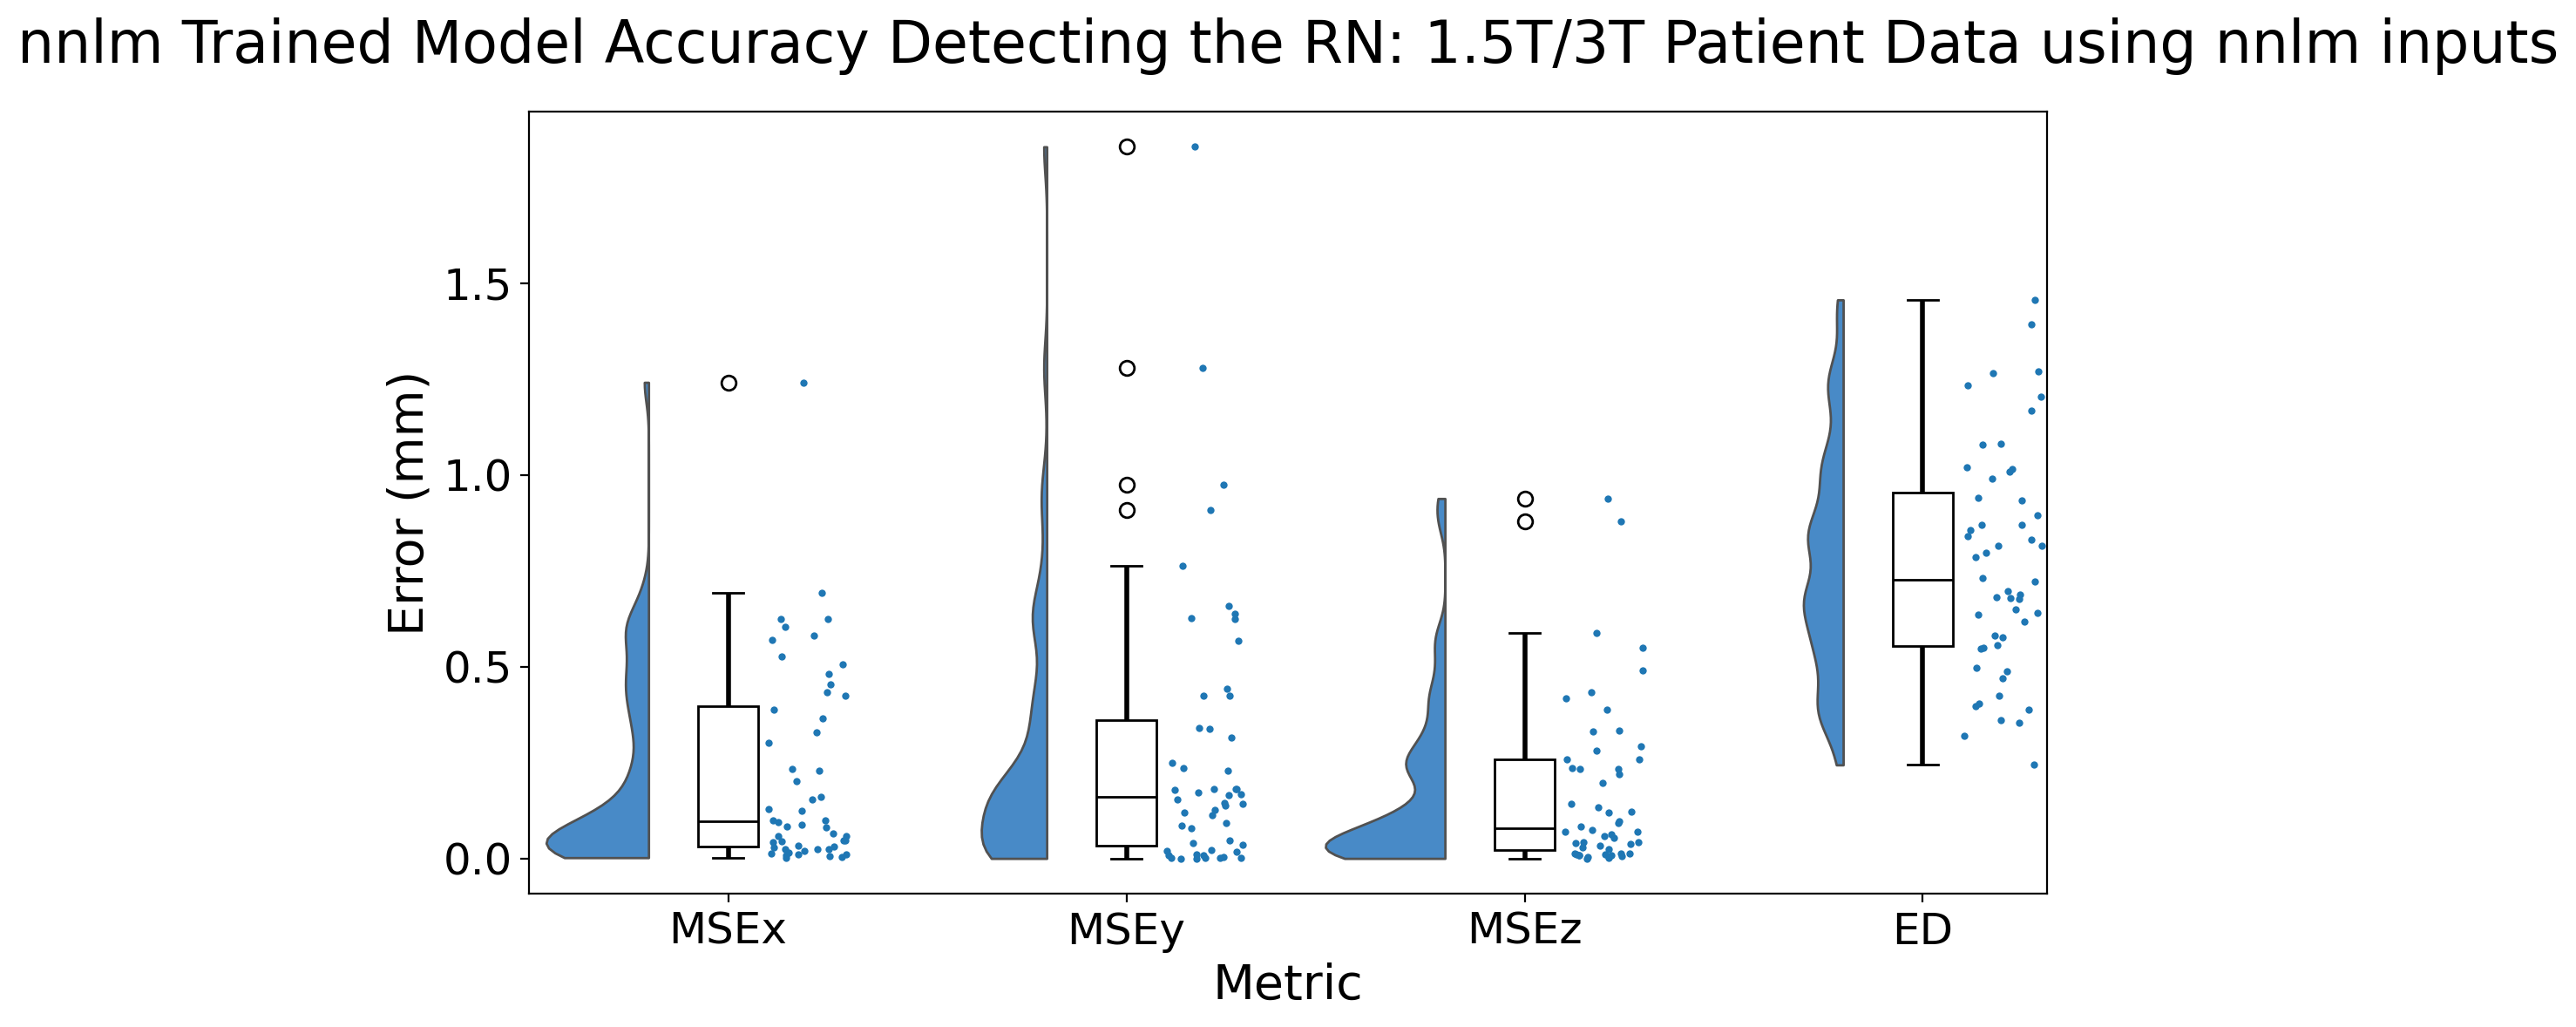

In [17]:
import matplotlib.pyplot as plt
import ptitprince as pt
import seaborn as sns

# 1. Load a standard sample dataset from Seaborn
nnlm_df = melted_nnlm_delta_errors

# 2. Initialize the matplotlib figure object
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create the raincloud plot using ptitprince
# x is the categorical grouping variable, y is the numeric target variable
pt.RainCloud(
    x="metric",
    y="error",
    data=nnlm_df,
    color="#488AC7",  # Changed to a single color argument to avoid palette warning
    bw=0.2,  # Smoothness of the violin curve (bandwidth)
    width_viol=0.6,  # Width of the half-violin
    orient="v",  # Changed to 'v' for vertical layout
    move=0.2,  # Controls spacing between components
    ax=ax,
)

# 4. Clean up labels and display
ax.set_title("nnlm Trained Model Accuracy Detecting the RN: 1.5T/3T Patient Data using nnlm inputs", fontsize=24, pad=20) # Increased pad for better spacing
ax.set_xlabel("Metric", fontsize=20) # Swapped labels for vertical orientation
ax.set_ylabel("Error (mm)", fontsize=20) # Swapped labels for vertical orientation

# Increase tick label font size
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

plt.tight_layout()
plt.show()

In [18]:
grouped_stats_nnlm = nnlm_delta[['MSEx', 'MSEy', 'MSEz', 'ED']].describe()

# Prepare DataFrame for results
median_iqr_summary_DBS = []

for metric in ['MSEx', 'MSEy', 'MSEz', 'ED']:
    median_val = grouped_stats_nnlm.loc['50%', metric]
    q1_val = grouped_stats_nnlm.loc['25%', metric]
    q3_val = grouped_stats_nnlm.loc['75%', metric]
    iqr_val = q3_val - q1_val # IQR is Q3 - Q1

    median_iqr_summary_DBS.append({
        'metric': metric,
        'median': median_val,
        'q1': q1_val,
        'q3': q3_val,
        'iqr': iqr_val
    })

median_iqr_df_DBS = pd.DataFrame(median_iqr_summary_DBS)
print("DBS Data Segmentation Errors (Median and IQR) for nnlm model:")
display(median_iqr_df_DBS)

DBS Data Segmentation Errors (Median and IQR) for nnlm model:


,metric,median,q1,q3,iqr
0,MSEx,0.096053,0.031115,0.397022,0.365908
1,MSEy,0.160249,0.032254,0.361562,0.329307
2,MSEz,0.079181,0.021706,0.258351,0.236645
3,ED,0.726771,0.554313,0.953328,0.399015
